<a href="https://colab.research.google.com/github/bhargavanarasimhaai24/Statistical-Modelling/blob/main/Simple%20Linear%20regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

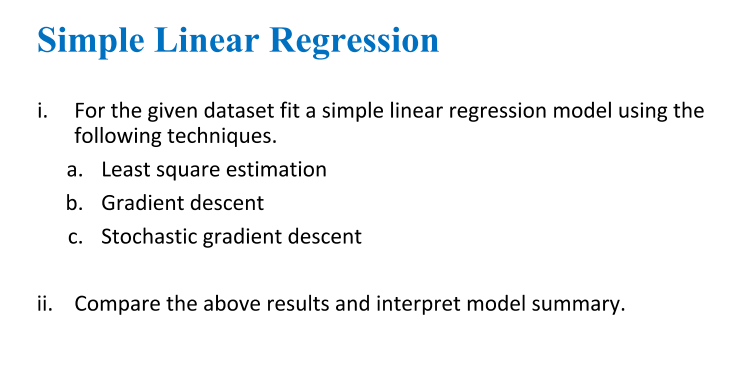

In [10]:
import numpy as np
import matplotlib.pyplot as plt

#Least Square Estimation

In [11]:
class LMS:
  def __init__(self):
    self.m = None
    self.c = None
  def fit(self, X, y):
    x_mean, y_mean = X.mean(), y.mean()
    self.m = np.sum((X-x_mean)*(y-y_mean)) / np.sum((X-x_mean)**2)
    self.c = y_mean - (self.m*x_mean)

In [12]:
X = np.array([15.50, 23.75, 8.00, 17.00, 5.50, 19.00, 24.00, 2.50, 7.50, 11.00, 13.00, 3.75, 25.00, 9.75, 22.00, 18.00, 6.00, 12.50, 2.00, 21.50])
y = np.array([2158.70, 1678.15, 2316.00, 2061.30, 2207.50, 1708.30, 1784.70, 2575.00, 2357.90, 2256.70, 2165.70, 2399.55, 1779.80, 2336.75, 1765.30, 2053.50, 2414.40, 2200.50, 2654.20, 1753.70])

obj = LMS()
obj.fit(X, y)
m, c = obj.m, obj.c
print(f"Learned Parameters: \nm{np.round(m, 4)}\nc:{np.round(c, 4)}")
print(f"Therefore prediction line is: y = {np.round(m, 4)}*x + {np.round(c, 4)}")

Learned Parameters: 
m-37.1538
c:2627.8495
Therefore prediction line is: y = -37.1538*x + 2627.8495


#Gradient Descent

In [13]:
class GD:
  def __init__(self, epochs= 100, eta= 0.01):
    self.epochs = epochs
    self.eta = eta
    self.m = None
    self.c = None
  def transform_data(self, X):
    return (X - X.mean())/(X.std())
  def initialise_weights(self):
    self.m = np.random.rand()
    self.c = np.random.rand()
  def fit(self, X, y):
    self.initialise_weights()
    X = self.transform_data(X)

    n = len(X)
    for epoch in range(self.epochs):
      y_hat = self.m * X + self.c

      dm = (-2/n) * np.sum((y - y_hat)*X)
      dc = (-2/n) * np.sum((y - y_hat))
      self.m = self.m - (self.eta * dm)
      self.c = self.c - (self.eta * dc)

In [14]:
X = np.array([15.50, 23.75, 8.00, 17.00, 5.50, 19.00, 24.00, 2.50, 7.50, 11.00, 13.00, 3.75, 25.00, 9.75, 22.00, 18.00, 6.00, 12.50, 2.00, 21.50])
y = np.array([2158.70, 1678.15, 2316.00, 2061.30, 2207.50, 1708.30, 1784.70, 2575.00, 2357.90, 2256.70, 2165.70, 2399.55, 1779.80, 2336.75, 1765.30, 2053.50, 2414.40, 2200.50, 2654.20, 1753.70])

obj = GD(200, 0.01)
obj.fit(X, y)

GD_m, GD_c = obj.m, obj.c
print(f"\nFinal parameters after {obj.epochs} iterations:")
print(f"beta_0 (Intercept c): {obj.c:.4f}")
print(f"beta_1 (Slope m): {obj.m:.4f}")

#For plotting purposes: as we have changed/scaled X
m_original_GD = obj.m / X.std()
c_original_GD = obj.c - (obj.m * X.mean() / X.std())


Final parameters after 200 iterations:
beta_0 (Intercept c): 2093.9040
beta_1 (Slope m): -271.4849


#Stochastic Gradient Descent

In [43]:
class SGD:
  def __init__(self, epochs= 100, eta= 0.01):
    self.epochs = epochs
    self.eta = eta
    self.m = None
    self.c = None
  def transform_data(self, X):
    return (X - X.mean())/(X.std())
  def initialise_weights(self):
    self.m = np.random.rand()
    self.c = np.random.rand()
  def fit(self, X, y):
    self.initialise_weights()
    X = self.transform_data(X)

    n = len(X)
    for epoch in range(self.epochs):

      idxs = np.random.permutation(n)
      for idx in idxs:
        y_hat = self.m * X[idx] + self.c

        dm = -2 * np.sum((y[idx] - y_hat)*X[idx])
        dc = -2 * np.sum((y[idx] - y_hat))
        self.m = self.m - (self.eta * dm)
        self.c = self.c - (self.eta * dc)

In [52]:
import numpy as np

X = np.array([15.50, 23.75, 8.00, 17.00, 5.50, 19.00, 24.00, 2.50, 7.50, 11.00, 13.00, 3.75, 25.00, 9.75, 22.00, 18.00, 6.00, 12.50, 2.00, 21.50])
y = np.array([2158.70, 1678.15, 2316.00, 2061.30, 2207.50, 1708.30, 1784.70, 2575.00, 2357.90, 2256.70, 2165.70, 2399.55, 1779.80, 2336.75, 1765.30, 2053.50, 2414.40, 2200.50, 2654.20, 1753.70])

obj = SGD(200, 0.01)
obj.fit(X, y)

SGD_m, SGD_c = obj.m, obj.c
print(f"\nFinal parameters after {obj.epochs} iterations:")
print(f"beta_0 (Intercept c): {obj.c:.4f}")
print(f"beta_1 (Slope m): {obj.m:.4f}")

#For plotting purposes: as we have changed/scaled X
m_original_SGD = obj.m / X.std()
c_original_SGD = obj.c - (obj.m * X.mean() / X.std())


Final parameters after 200 iterations:
beta_0 (Intercept c): 2131.3733
beta_1 (Slope m): -273.6752


#Comparing the results

In [53]:
def util(m, c):
  y = m*x+c
  return y

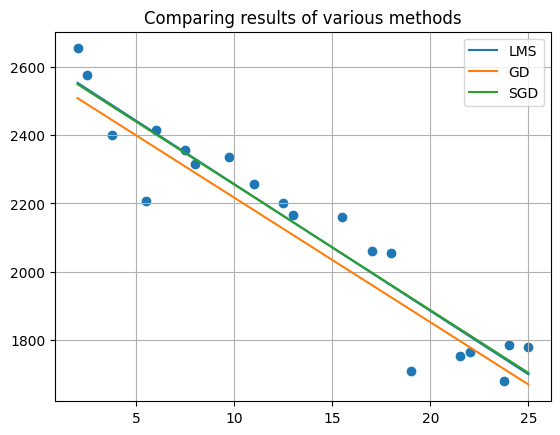

In [54]:
x = np.linspace(X.min(), X.max(), 100)
plt.scatter(X, y)
plt.plot(x, util(m, c), label="LMS")
plt.plot(x, util(m_original_GD, c_original_GD), label="GD")
plt.plot(x, util(m_original_SGD, c_original_SGD), label="SGD")
plt.title("Comparing results of various methods")
plt.legend()
plt.grid()
plt.show()

Observations made:

1. Least Squares (LMS) directly computes the optimal parameters for
   simple linear regression using a closed-form solution. GD and SGD,
   on the other hand, iteratively search for the optimum, so their
   convergence depends on hyperparameters such as learning rate and
   number of epochs.

2. Although Least Squares gives the solution directly for simple
   linear regression, GD/SGD are important because many ML/DL models,
   such as neural networks, do not have a closed-form solution.
   Gradient-based methods can also be applied to problems with large
   datasets and many parameters.

3. In this experiment, both GD and SGD converged to almost the same
   solution as Least Squares. In fact, with the same learning rate and
   number of epochs, SGD also produced a line that almost coincided
   with the LMS line.

4. The similar final results do not mean GD and SGD work identically.
   GD calculates each update using the entire dataset, whereas SGD
   updates the parameters using one sample at a time. Therefore,
   SGD generally has noisier updates and its convergence can vary
   depending on the order of samples and hyperparameters.

5. Since the MSE loss for linear regression is convex, GD can converge
   to the global minimum with a suitable learning rate and sufficient
   iterations. SGD can also converge close to this minimum, but its
   path toward the minimum is more noisy due to sample-wise updates.